# Wrap-Up zur Datenanalyse in `pandas`

* Daten laden
* Daten explorieren
* Daten visualisieren
* Unsupervised learning mit `sklearn`

In [4]:
from pandas import read_csv
from matplotlib import pyplot as plt
from os.path import isdir
from os import makedirs
from seaborn import pairplot, clustermap, heatmap

## Daten Laden

In [5]:
# Damit wir Daten laden können, müssen wir diese zuerst in Colab hochladen!!!!
# Dann können die Daten mit read_csv gelesen werden
df = read_csv("../data/titanic.csv")

## Data Exploration

In [6]:
# Überblicksdarstellung unseres Dataframes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# Einfache deskriptive Statistik aller nummerischen Attribute
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Ausgabe der ersten/letzten Datensätze
df.head(2) # und df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


## Data Visualization

<Axes: ylabel='Frequency'>

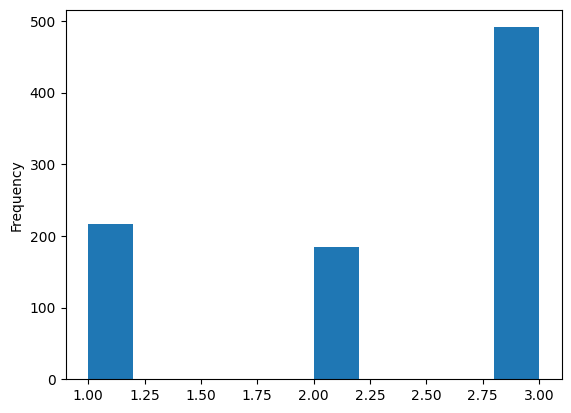

In [9]:
df["Pclass"].plot(kind="hist")

<Axes: ylabel='Pclass'>

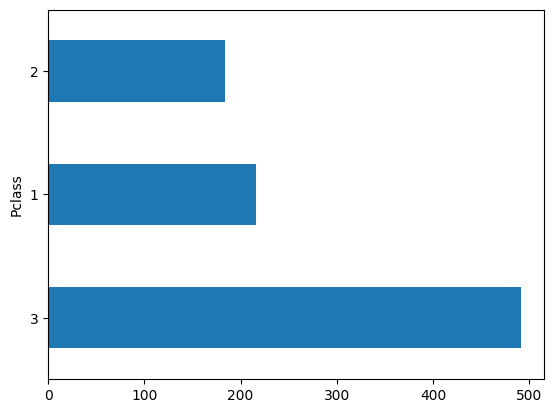

In [10]:
df['Pclass'].value_counts().plot(kind="barh")

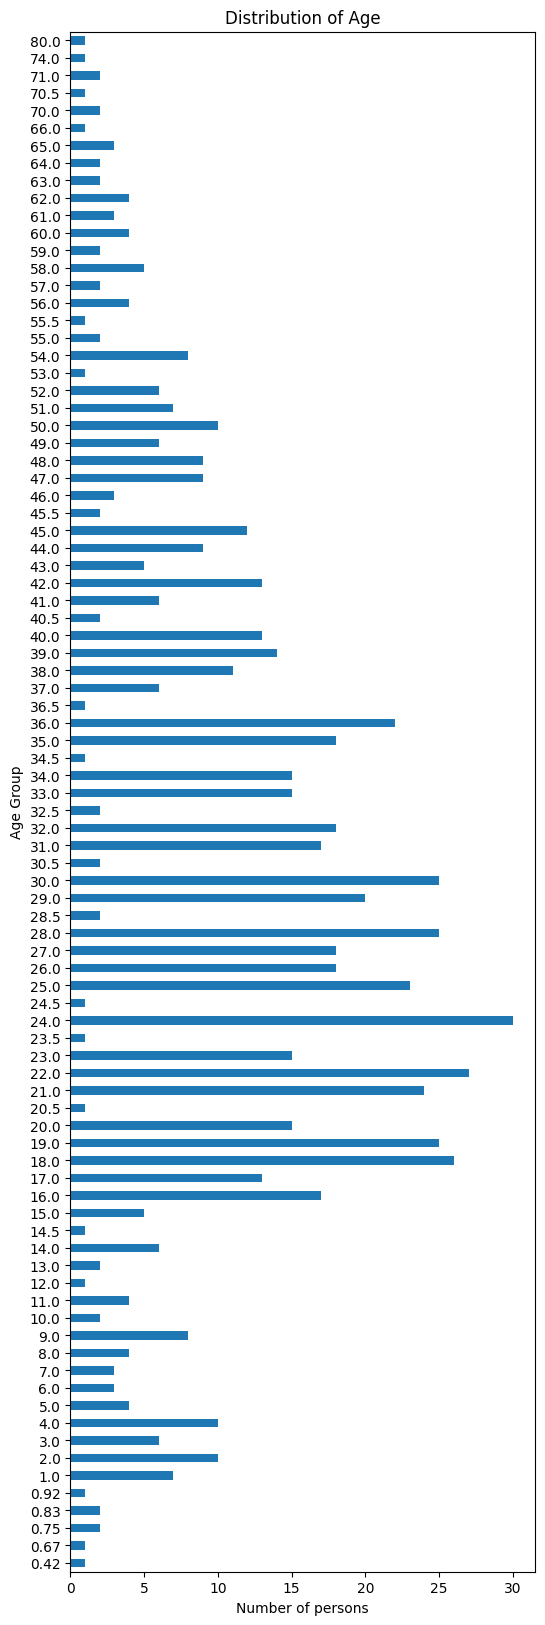

In [11]:
if isdir("output") == False:
    makedirs("output")

df['Age'].value_counts().sort_index().plot(kind="barh", figsize=(6,20))
plt.title("Distribution of Age")
plt.xlabel("Number of persons")
plt.ylabel("Age Group")
plt.savefig("output/age_plot.png")

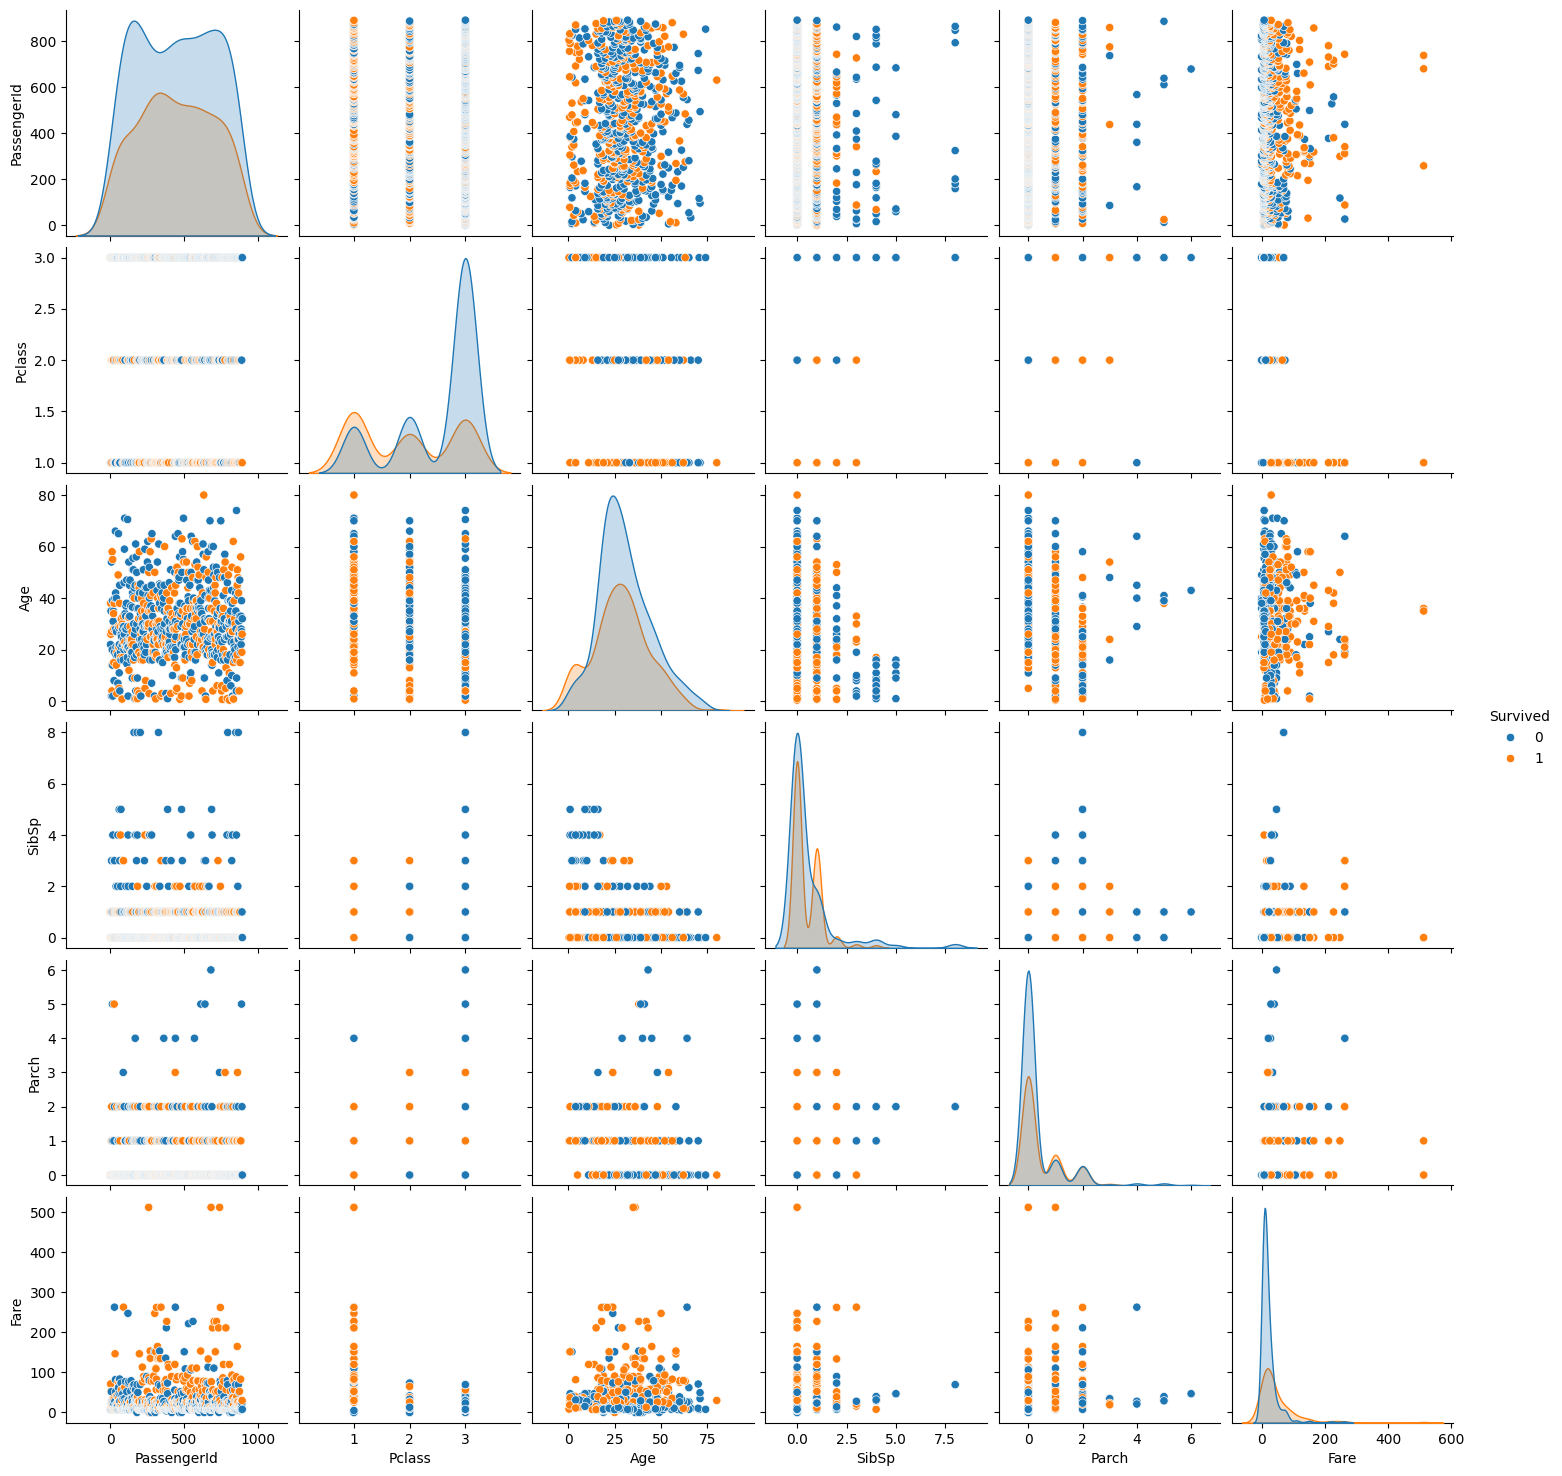

In [12]:
# Schneller Überblicksplot über alle NUMMERISCHEN Merkmale
pairplot(df, hue="Survived")
plt.savefig("output/pairplot.png")

# Herausgreifen von bestimmten Features, falls unser DataFrame ansonsten zu groß würde
# pairplot(df[['Age', "Pclass", "Fare", "Survived"]], hue="Survived")

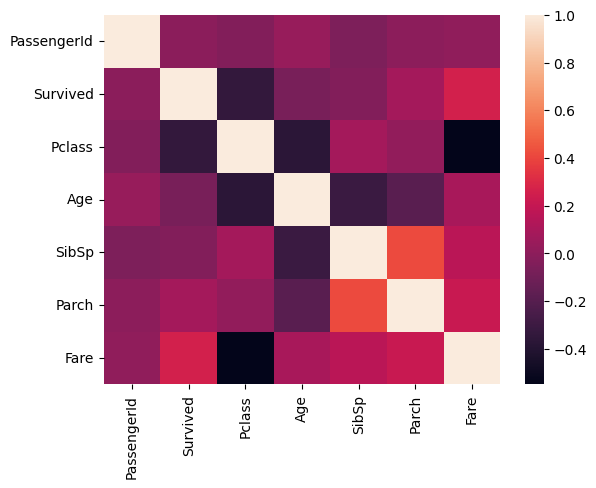

In [13]:
heatmap(df.select_dtypes(include="number").corr())
plt.savefig("output/heatmap.png")

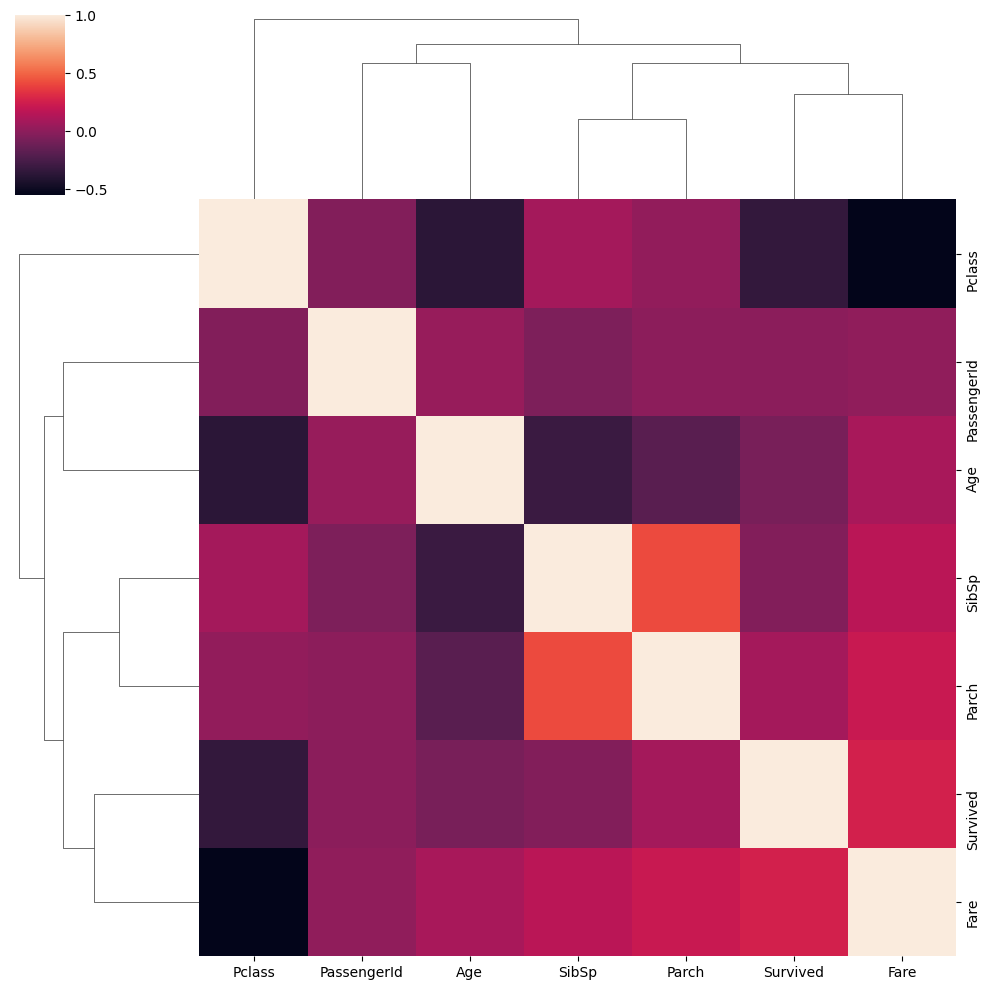

In [14]:
clustermap(df.select_dtypes(include="number").corr())
plt.savefig("output/clustermap.png")

## Data Preprocessing

In [15]:
# Umwandeln der Spalte Sex in eine nummerische Spalte
mapping_dictionary = {"male": 0, "female": 1}
df["Sex"] = df["Sex"].map(mapping_dictionary)

In [16]:
# Umgang mit fehlenden Werten (Achtung: Hier gibt es kein richtig oder falsch)
# df = df.dropna()
# df["Age"] = df["Age"].fillna(-999)
df["Age"] = df["Age"].fillna(df["Age"].median())

## Preparation for Machine Learning

In [17]:
target = 'Survived'
used_columns = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch'
]

In [18]:
df[used_columns]

,Pclass,Sex,Age,SibSp,Parch
0,3,0,22.0,1,0
1,1,1,38.0,1,0
2,3,1,26.0,0,0
3,1,1,35.0,1,0
4,3,0,35.0,0,0
...,...,...,...,...,...
886,2,0,27.0,0,0
887,1,1,19.0,0,0
888,3,1,28.0,1,2
889,1,0,26.0,0,0
